# Tuesday Challenge: creating the best ERK2 scoring function ‼️

## Challenge 1/2 - keeping it small

**Author:** [Albert J. Kooistra](https://drug.ku.dk/staff/?pure=en/persons/612712), 2023-2025, University of Copenhagen

Yesterday we gained insights into our protein target ERK2. Additionally, we dug deeper into: docking, docking scores, docking scoring features, protein-ligand interactions, and retrospectively evaluating docking scores.

And today we are going to put all the knowledge you've acquired to a test 😁

What we did not tell you is that we removed 25% of the original experimental dataset on ERK2. The goal of today is to use a combination of the insights that you've gained and mix it with different machine learning methods to create an optimal scoring function for ERK2. In the end, you have to apply your best scoring function(s) to the compounds with unknown activity and submit the final predictions to us.

Each group has two submissions for each challenge and we will unveil the winning group(s) during the Feedback session next week 🏆

## Installation and import of libraries and functions

Simply execute the code cells below to get started.

In [1]:
# Installing missing libraries necessary for processing the docking poses
!pip install -q rdkit prolif==1.1.0
!pip install -q py3Dmol

In [2]:
# Import packages and libraries
import matplotlib.pyplot as plt
import MDAnalysis as mda
import numpy as np
import os
import pandas as pd
import prolif as plf
import py3Dmol
import re
import seaborn as sns

# Cherry-picking parts of packages
from ipywidgets import interact, fixed, IntSlider
from rdkit import Chem
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from prolif.plotting.network import LigNetwork
from rdkit import Geometry

# Disabling warnings (can be tricky)
import warnings
warnings.filterwarnings('ignore')

/opt/conda/lib/python3.12/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


In [3]:
# HELPER FUNCTIONS
# No need to read the code or interpret

# Hover functions for the molecular viewer (Javascript code)
hover_func = """
  function(atom,viewer) {
    if (!atom.label) 
      atom.label = viewer.addLabel(atom.resn + " " + atom.resi,
      {position: atom, backgroundColor: 'black', fontColor:'white'});
  }"""

# Unhover function for the molecular viewer (Javascript code)
unhover_func = """function(atom,viewer) {if (atom.label) { viewer.removeLabel(atom.label); delete atom.label; }}"""

# proLIF - redefining HB-acceptors (slightly wider angle)
class HBAcceptor(plf.interactions.HBAcceptor):
   def __init__(self): 
     super().__init__(angles=(120, 180))

# proLIF - redefining HB-donors (slightly wider angle)
class HBDonor(plf.interactions.HBDonor):
   def __init__(self): 
      super().__init__(angles=(120, 180))

# Functions based on TeachOpenCADD - T007
# https://projects.volkamerlab.org/teachopencadd/index.html

def plot_roc_curves_for_models(score_column, data, save_png = False, negative_scores = True):
    """
    Helper function to plot customized roc curve.

    Parameters
    ----------
    score_column: string
        Name of the column with the scores
    data: dataframe
        Dataframe with two columns: <Score> and "Active"
    save_png: bool
        Save image to disk (default = False)

    Returns
    -------
    fig:
        Figure.
    """

    
    if negative_scores:
      data = data.copy()
      data[score_column] = -1 * data[score_column]

    fig, ax = plt.subplots()
    fig.set_dpi(150)

    # Compute ROC plot with False postive rate and True positive rate
    fpr, tpr, thresholds = roc_curve(data["Active"], data[score_column], pos_label=1)

    # Calculate Area under the curve to display on the plot
    auc = roc_auc_score(data["Active"], data[score_column])

    # Plot the computed values
    ax.plot(fpr, tpr, label=(f"{score_column} AUROC = {auc:.2f}"))

    # Custom settings for the plot
    ax.plot([0, 1], [0, 1], "r--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Receiver Operating Characteristic")
    ax.legend(loc="lower right")

    # Save plot
    if save_png:
        fig.savefig(f"{DATA}/roc_auc", dpi=300, bbox_inches="tight", transparent=True)

    return fig

## Setting the stage: getting all data

In [4]:
# Getting the full data package and extract
# Only do this if we don't already have it!
if not os.path.isfile("Week_5_Tuesday_dataset_chal1.tgz"):
    # Downloading the dataset
    ! wget -q --show-progress "https://www.dropbox.com/s/upwyc75nkqffpxt/Week_5_Tuesday_dataset.tgz?dl=1" -O Week_5_Tuesday_dataset_chal1.tgz
    # Extracting the dataset
    ! tar -xvzf Week_5_Tuesday_dataset_chal1.tgz 2>/dev/null

In [5]:
%ls *

AF_model.pdb                      klifs_4xj0_protein.pdb
Week_3_Tuesday_Challenge_1.ipynb  reference_ligand.pdb
Week_5_Tuesday_dataset_chal1.tgz  submission_example.csv
klifs_4fv7_protein.pdb            training_set.txt
klifs_4qpa_protein.pdb

4fv7_docked:
challenge_features.csv.gz  training_features.csv.gz
challenge_ifp.csv.gz       training_ifp.csv.gz

4qpa_docked:
challenge_features.csv.gz  training_features.csv.gz
challenge_ifp.csv.gz       training_ifp.csv.gz

4xj0_docked:
challenge_features.csv.gz  training_features.csv.gz
challenge_ifp.csv.gz       training_ifp.csv.gz

af_docked:
challenge_features.csv.gz  training_features.csv.gz
challenge_ifp.csv.gz       training_ifp.csv.gz

compounds:
challenge.smi  training.smi


### Checking the data

In the main folder we have different PDB files:
* 3x ERK2 crystal structure in different conformations
* 1x AlphaFold model
* 1x the experimentally-determined binding mode of our mystery reference ligand E94
* 1x training_set.txt - the classification active/inactive for our training ligands
* 1x The data archive (the .tgz file)
* 1x this notebook

Then we have a compounds folder:
* training.smi - the molecular structure of the training compounds in SMILES format
* challenge.smi - the molecular structure of the challenge compounds in SMILES format

And finally, we have pre-docked all compounds, both from the training and challenge set, into all proteins. For each protein structure/model, we have one <code/name>\_docked folder. In each folder you will find:
* training_features.csv.gz - docking scores and features for the training compounds
* challenge_features.csv.gz - docking scores and features for the challenge compounds
* training_ifp.csv.gz - interaction fingerprints for the training compounds
* challenge_ifp.csv.gz - interaction fingerprints for the challenge compounds

‼️ Note: we obtained 10 docking poses for each compounds, but in a few cases we had multiple isomers of a compound resulting in more than 10 docking poses for the same compound.

Below a few examples of reading in the data. Note that you can borrow code from yesterdays notebook as well!

In [6]:
# Reading in the docking scores and ifp from docking the 4FV7 protein structure
features = pd.read_csv("4fv7_docked/training_features.csv.gz")
print("=== FEATURES ===")
print(features.head())

ifp = pd.read_csv("4fv7_docked/training_ifp.csv.gz")
print("=== INTERACTIONS ===")
print(ifp.head())

# Reading in the labels/classes for the compounds in the training set
cpd_classes = pd.read_csv("training_set.txt", dtype=str, index_col=0)
cpd_classes["Active"] = cpd_classes["Active"].astype(int)
print("=== LABELS/CLASSES ===")
cpd_classes.head()

=== FEATURES ===
                                  TOTAL_SCORE  SCORE_RB_PEN  \
ERK057898806_entry_00001_conf_01     -80.9700      -74.9700   
ERK057898806_entry_00001_conf_02     -74.7032      -68.7032   
ERK057898806_entry_00001_conf_03     -72.4452      -66.4452   
ERK057898806_entry_00001_conf_04     -71.4635      -65.4635   
ERK057898806_entry_00001_conf_05     -69.4314      -63.4314   

                                  SCORE_NORM_HEVATOMS  \
ERK057898806_entry_00001_conf_01             -4.04850   
ERK057898806_entry_00001_conf_02             -3.73516   
ERK057898806_entry_00001_conf_03             -3.62226   
ERK057898806_entry_00001_conf_04             -3.57317   
ERK057898806_entry_00001_conf_05             -3.47157   

                                  SCORE_NORM_CRT_HEVATOMS  SCORE_NORM_WEIGHT  \
ERK057898806_entry_00001_conf_01                 -29.8296          -0.294124   
ERK057898806_entry_00001_conf_02                 -27.5209          -0.271360   
ERK057898806_entry_00

,Active
CPD_ID,
ERK000048428,0
ERK000424045,0
ERK000501211,0
ERK001074324,0
ERK001580515,0


Take a look at the memory usage indicator on top. By now we have already used quite a bit and haven't even gotten started. So just to clean up, to delete your (unused) variables again when you don't need them anymore. This dataset is not too big, but for challenge 2 this will be key!

In [7]:
del features
del ifp
del cpd_classes

## Building a scoring function

This is (of course) the key and fun part 😁\
However, keep in mind that machine learning alone is not the only way to go and you can incorporate knowledge you have gained from yesterday's analysis!

On top, we have quite some input to be used for our machine learning:
* Docking in 4 structures each yielding 27 features
* Interaction FingerPrints for each docking yielding ~140 features per docking structure
* At least 10 docking poses per compound to select from per docking structure

Follow roughly the following steps to create a scoring function:
*Training your model*:
* Select your data sources and read them
* Perform a feature selection - which features are you going to use as input for machine learning
* Merge the selected data sets
* MEMORY: if your memory usage is high, make a copy() of your dataframe and delete large variables
* Determine a strategy to perform the pose selection and reduce/clean your dataset (1 pose per compound)
* Add the activity class at the end of your dataset
* Test different classification methodologies - borrow from the code examples at the end of this notebook, from other notebooks, or use Google/ChatGPT
* Evaluate your models using ROC-curves and especially the early enrichment (EF1%)
* Repeat this until you are happy with your resulting model
* OPTIONAL: based on the available data, feel free to generate new features and add them to your dataset to enhance your model

*Applying your model*:
* Select the same data sources as used for training your model
* Merge them into a single dataframe in the same way (but this time without the activity class, since they are unknown)
* Apply your machine learning model to the challenge dataframe
* Generate a submission CSV containing the compound ID and the classification outcome
* Submit!

Use the code boxes below the example to generate your models and submission and don't forget to interpret the resulting scoring function!

In [8]:
### EXAMPLE - creation of a scoring method

# STEP 1 - Data sources
# I've decided to use the docking score features from both 4XJ0 and the AlphaFold model
# And the interactions from the 4XJ0 docking
feat_alfo = pd.read_csv("af_docked/training_features.csv.gz")
feat_4xj0 = pd.read_csv("4fv7_docked/training_features.csv.gz")
ifps_4xj0 = pd.read_csv("4fv7_docked/training_ifp.csv.gz")

# STEP 2 - Feature selection
# I only want to use the non-normalized scores, so dropping the columns with _NORM_ in the name
feat_columns = feat_alfo.columns.tolist()
norm_columns = [col_name for col_name in feat_columns if "_NORM_" in col_name]
feat_alfo.drop(norm_columns, axis = 1, inplace = True)
feat_4xj0.drop(norm_columns, axis = 1, inplace = True)

# For the IFPs I only want to keep hydrophobic interactions
ifp_columns = ifps_4xj0.columns.tolist()
hyd_columns = [col_name for col_name in ifp_columns if "_Hydrophobic" in col_name]
ifps_4xj0 = ifps_4xj0[hyd_columns]

# STEP 3 - merging the datasets
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html
# We are merging on the index - the row ID - consisting of the compound ID + conformation and pose number
feat_all = pd.merge(feat_alfo, feat_4xj0, left_index = True, right_index = True)
feat_all = pd.merge(feat_all, ifps_4xj0, left_index = True, right_index = True)

# STEP 4 - we have a new dataframe with everything combined - so we can remove the originals
del feat_alfo
del feat_4xj0
del ifps_4xj0

# STEP 5 - pose selection (good point to rerun part of the analysis from yesterday!)
# From my earlier analysis I think that the total score is actually not too bad
# So I'm creating a new column which combines the TOTAL_SCORE from both docking results
feat_all["pose_selection"] = feat_all["TOTAL_SCORE_x"] + feat_all["TOTAL_SCORE_y"]

# Sorting the dataframe by the values in this new column and remove the column
feat_all.sort_values(by=["pose_selection"], inplace = True)
feat_all.drop("pose_selection", axis = 1, inplace = True)

# Selecting the first occurrence of each compound ID
# First get the compound ID
feat_all["CPD_ID"] = [row_id.split("_")[0] for row_id in feat_all.index]
# Then remove all rows except the first occurrence for each compound (the one with the lowest pose_selection)
feat_all.drop_duplicates("CPD_ID", keep="first", inplace = True)
# So we can now also replace the row ID with the cpd ID (as a number)
feat_all.index = feat_all["CPD_ID"]
feat_all.drop("CPD_ID", axis = 1, inplace = True)

# STEP 6 - add the activity classes
cpd_classes = pd.read_csv("training_set.txt", dtype=str, index_col=0)
cpd_classes["Active"] = cpd_classes["Active"].astype(int)
feat_all = pd.merge(feat_all, cpd_classes, on="CPD_ID")

# TIDYING UP
del cpd_classes

# PREPARATION DONE - check the output
print(feat_all.shape)
feat_all.head()

(3703, 77)


,TOTAL_SCORE_x,SCORE_RB_PEN_x,PLPtotal_x,PLPparthbond_x,PLPpartsteric_x,PLPpartmetal_x,PLPpartrepulsive_x,PLPpartburpolar_x,LIG_NUM_CLASH_x,LIG_NUM_CONTACT_x,...,PRO150.A_Hydrophobic,ASN152.A_Hydrophobic,LEU154.A_Hydrophobic,CYS164.A_Hydrophobic,ASP165.A_Hydrophobic,PHE166.A_Hydrophobic,LEU168.A_Hydrophobic,THR188.A_Hydrophobic,TYR191.A_Hydrophobic,Active
CPD_ID,,,,,,,,,,,,,,,,,,,,,
ERK993933844,-102.4330,-88.4326,-77.2739,-1.850160,-68.2573,0,1.790630,0.000000,3,27,...,0,0,1,0,1,0,0,0,0,1
ERK837156036,-101.2800,-89.2799,-80.6090,-3.000000,-72.2631,0,0.292190,-0.055412,7,25,...,0,0,1,0,1,0,0,0,0,0
ERK394158705,-102.4480,-84.4485,-91.2542,-0.972548,-85.1813,0,1.413640,0.000000,5,31,...,0,0,1,0,1,0,0,0,0,0
ERK299584781,-99.3140,-83.3140,-88.5740,-3.764990,-79.4395,0,0.418649,0.000000,4,32,...,0,0,1,0,0,0,0,0,0,0
ERK663030417,-98.9033,-78.9033,-72.8404,-5.630490,-60.8323,0,0.789741,0.000000,3,30,...,0,0,1,0,1,0,0,0,0,0


In [9]:
# PREP - import the libraries for your ML 
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics  import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [10]:
# STEP 7 - building a classification model
input_features = feat_all.drop("Active", axis = 1)
outcome = feat_all["Active"]
x_train, x_test, y_train, y_test = train_test_split(input_features, outcome, test_size=0.2, stratify=outcome)

model = LogisticRegression()
model.fit(x_train, y_train)

# STEP 8 - Evaluation - ROC and EF1% evaluation
pred = model.predict(x_test)

# for classification we use accuracy and F1 score
acc_score = accuracy_score(y_test, pred)
f1 = f1_score(y_test, pred)
print(f"RESULT - accuracy is {round(acc_score, 2)} and F1-score is {round(f1, 2)}")

RESULT - accuracy is 0.98 and F1-score is 0.13


ACTUAL classes - ACTIVE 13 out of 741
PREDICTED classes - ACTIVE 2 out of 741

UNIQUE classes count
Active
0    3640
1      63
Name: count, dtype: int64

PREDICTED classes count
0
0    739
1      2
Name: count, dtype: int64


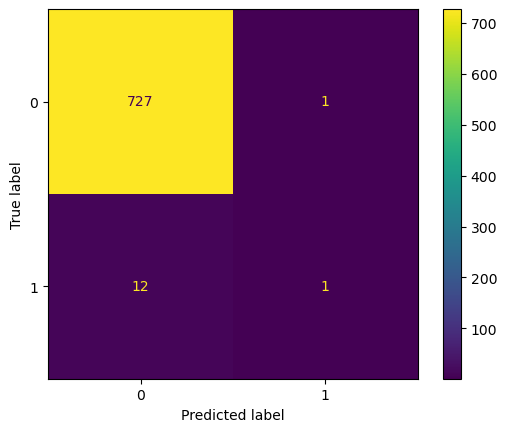

In [11]:
# WAIT! What just happened?
print(f"ACTUAL classes - ACTIVE {sum(y_test)} out of {len(y_test)}")
print(f"PREDICTED classes - ACTIVE {sum(pred)} out of {len(pred)}")

print("\nUNIQUE classes count")
print(feat_all["Active"].value_counts())

print("\nPREDICTED classes count")
print(pd.DataFrame(pred).value_counts())

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
# So ok, this one can go straight into the 🚽

In [12]:
#### IMBALANCED-LEARN ####
!pip install -q imbalanced-learn

import imblearn
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE, KMeansSMOTE

# Code adapted from https://learn-scikit.oneoffcoder.com/imbalanced-learn.html
# A function to create samplers for oversampling/upscaling our underrepresented dataset
# This functions takes a name of an oversampling algorithm and returns a sampler with default settings 
def get_oversampler(sampler):
    if "adasyn" == sampler:
        params = { "random_state": 42, "n_neighbors": 5 }
        return ADASYN(**params)
    elif "borderlinesmote" == sampler:
        params = { "random_state": 42, "k_neighbors": 5, "m_neighbors": 10 }
        return BorderlineSMOTE(**params)
    elif "smote" == sampler:
        params = { "random_state": 42, "k_neighbors": 5 }
        return SMOTE(**params)
    elif "svmsmote" == sampler:
        params = { "random_state": 42, "k_neighbors": 5, "m_neighbors": 10 }
        return SVMSMOTE(**params)
    elif "random" == sampler:
        params = { "random_state": 42 }
        return RandomOverSampler(**params)
    else:
        return False

Trying oversampling technique: random
Active
1    2912
0    2912
Name: count, dtype: int64
RESULT - accuracy is 0.88 and F1-score is 0.15


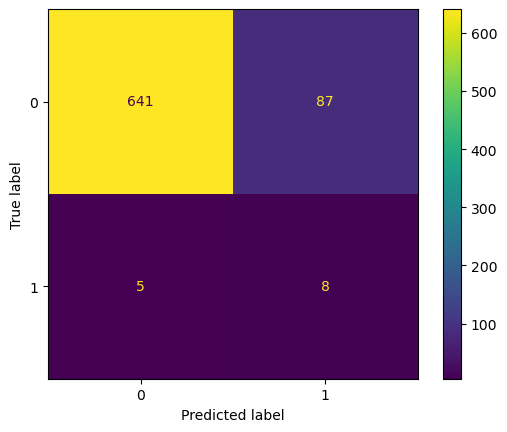

Trying oversampling technique: smote
Active
1    2912
0    2912
Name: count, dtype: int64
RESULT - accuracy is 0.93 and F1-score is 0.24


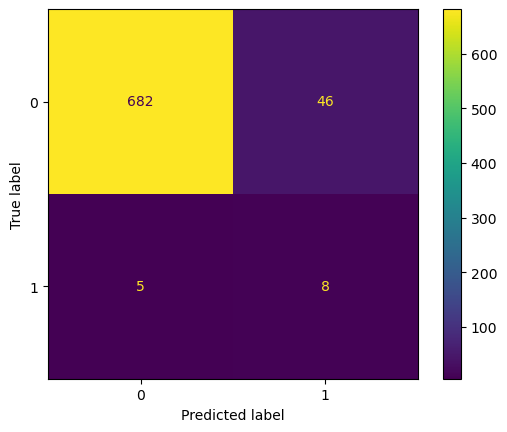

Trying oversampling technique: adasyn
Active
0    2912
1    2904
Name: count, dtype: int64
RESULT - accuracy is 0.92 and F1-score is 0.19


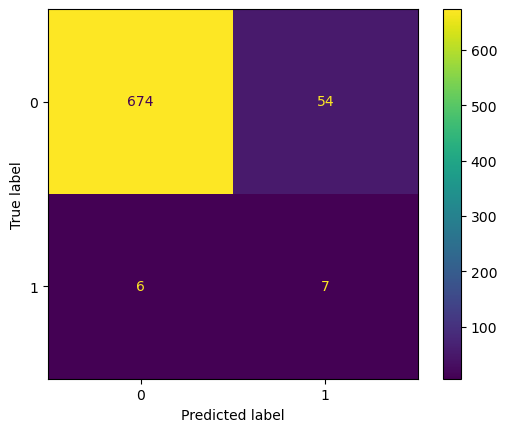

Trying oversampling technique: borderlinesmote
Active
1    2912
0    2912
Name: count, dtype: int64
RESULT - accuracy is 0.94 and F1-score is 0.21


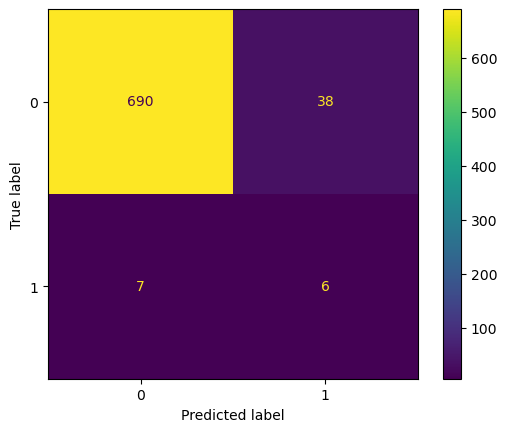

Trying oversampling technique: svmsmote
Active
1    2912
0    2912
Name: count, dtype: int64
RESULT - accuracy is 0.94 and F1-score is 0.23


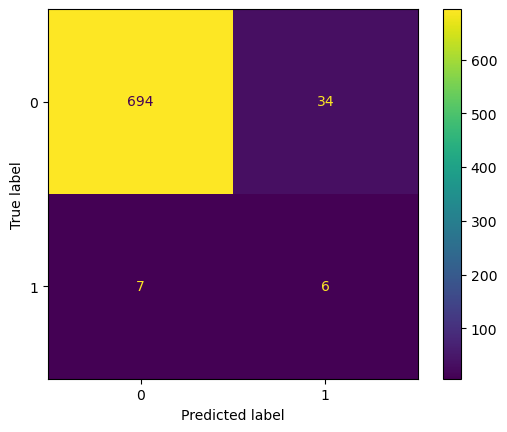

In [13]:
from sklearn.linear_model import LogisticRegression
        
samplers = ["random", "smote", "adasyn", "borderlinesmote", "svmsmote"]
for sampler in samplers:
    print(f"Trying oversampling technique: {sampler}")
    sampling_approach = get_oversampler(sampler)

    # Split dataset using the row IDs
    outcome = feat_all["Active"]
    train_idx, remain_idx = train_test_split(feat_all.index, train_size = 0.8, random_state = 42, stratify=outcome)
    train_x = feat_all.loc[train_idx].drop("Active", axis = 1).copy()
    train_y = feat_all.loc[train_idx]["Active"].copy()
    test = feat_all.loc[remain_idx]

    # Apply oversampler
    train_over_x, train_over_y = sampling_approach.fit_resample(train_x, train_y)
    
    # Check composition oversampled training dataset
    print(train_over_y.value_counts())
    
    # Step 7 => train our model again
    model = LogisticRegression(random_state=42)
    model.fit(train_over_x, train_over_y)

    # STEP 8
    pred = model.predict(test.drop("Active", axis = 1))
    
    # for classification we use accuracy and F1 score
    real_classes = test["Active"].copy()
    acc_score = accuracy_score(real_classes, pred)
    f1 = f1_score(real_classes, pred)
    print(f"RESULT - accuracy is {round(acc_score,2)} and F1-score is {round(f1,2)}")
    
    # Let's check
    cm = confusion_matrix(real_classes, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()

In [14]:
# FINAL MODEL creation
# So the borderlinesmote looks ok, let's use that one and train a new model on the full dataset
sampling_approach = get_oversampler("borderlinesmote")

# FULL dataset and apply the selected sampler
train_x = feat_all.drop("Active", axis = 1).copy()
train_y = feat_all["Active"].copy()
train_over_x, train_over_y = sampling_approach.fit_resample(train_x, train_y)

# Create model on full oversampled dataset
model = LogisticRegression(random_state=42)
model.fit(train_over_x, train_over_y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
# STEP 9 - prepare challenge dataset (repeat all steps we did for the training)
chal_feat_alfo = pd.read_csv("af_docked/challenge_features.csv.gz")
chal_feat_4xj0 = pd.read_csv("4fv7_docked/challenge_features.csv.gz")
chal_ifps_4xj0 = pd.read_csv("4fv7_docked/challenge_ifp.csv.gz")

# Feature selection (drop normalized scores and keep hydrophobic interactions)
chal_feat_alfo.drop(norm_columns, axis = 1, inplace = True)
chal_feat_4xj0.drop(norm_columns, axis = 1, inplace = True)
chal_ifp_columns = chal_ifps_4xj0.columns.tolist()
chal_hyd_columns = [col_name for col_name in chal_ifp_columns if "_Hydrophobic" in col_name]
chal_ifps_4xj0 = chal_ifps_4xj0[chal_hyd_columns]

# Merge
chal_feat_all = pd.merge(chal_feat_alfo, chal_feat_4xj0, left_index = True, right_index = True)
chal_feat_all = pd.merge(chal_feat_all, chal_ifps_4xj0, left_index = True, right_index = True)

# POSE SELECTION using our combined score
chal_feat_all["pose_selection"] = chal_feat_all["TOTAL_SCORE_x"] + chal_feat_all["TOTAL_SCORE_y"]
chal_feat_all.sort_values(by=["pose_selection"], inplace = True)
chal_feat_all.drop("pose_selection", axis = 1, inplace = True)

# Selecting the first occurrence of each compound ID
chal_feat_all["CPD_ID"] = [row_id.split("_")[0] for row_id in chal_feat_all.index]
chal_feat_all.drop_duplicates("CPD_ID", keep="first", inplace = True)
chal_feat_all.index = chal_feat_all["CPD_ID"]
chal_feat_all.drop("CPD_ID", axis = 1, inplace = True)

# STEP 10 - apply the model
chal_feat_all["PREDICTED"] = model.predict(chal_feat_all)

# FINALLY prep submission file
# This submission file should contain the following:
# - the compound ID or pose ID in the first column
# - predicted class Active (1) or Inactive (0) in the second column
submission = chal_feat_all["PREDICTED"]
# Write results to file for submission
submission.to_csv("submission_example.csv", header = False)
submission.head()

CPD_ID
ERK294573137    0
ERK123685810    1
ERK776590389    0
ERK187544534    0
ERK209634396    0
Name: PREDICTED, dtype: int64

# SCORING FUNCTION 1



Describe the reasoning behind scoring approach 1

In [ ]:
### YOUR CODE HERE

Describe the reasoning behind scoring approach 1

YOUR ANSWER HERE

In [ ]:
### YOUR CODE HERE

YOUR ANSWER HERE

Remember to store the results of the first and second scoring approach and submit your final results.

# DONE 🎉🎉!

In [ ]:
# BONUS - classifier code examples

### GAUSSIAN NAIVE BAYES
from sklearn.naive_bayes import GaussianNB

# Train our model
model = GaussianNB()
model.fit(train_over_x, train_over_y)
# Apply our model to the test set
pred = model.predict(test.drop("Active", axis = 1))


### LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

# Train our model
model = LogisticRegression(max_iter=1000, random_state = 42)
model.fit(train_over_x, train_over_y)
# Apply our model to the test set
pred = model.predict(test.drop("Active", axis = 1))


### K-NEAREST NEIGHBORS
from sklearn.neighbors import KNeighborsClassifier

# Train our model
model = KNeighborsClassifier(algorithm = 'brute', n_jobs = -1)
model.fit(train_over_x, train_over_y)
# Apply our model to the test set
pred = model.predict(test.drop("Active", axis = 1))


### SUPPORT VECTOR MACHINES
from sklearn.svm import LinearSVC

# Train our model
model = LinearSVC(C=0.0001)
model.fit(train_over_x, train_over_y)
# Apply our model to the test set
pred = model.predict(test.drop("Active", axis = 1))


### DECISION TREE
from sklearn.tree import DecisionTreeClassifier

# Train our model
model = DecisionTreeClassifier()
model.fit(train_over_x, train_over_y)
# Apply our model to the test set
pred = model.predict(test.drop("Active", axis = 1))


### RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

# Train our model
model = RandomForestClassifier(n_estimators=30, max_depth=9)
model.fit(train_over_x, train_over_y)
# Apply our model to the test set
pred = model.predict(test.drop("Active", axis = 1))


### GRADIENT BOOSTING
from sklearn.ensemble import GradientBoostingClassifier

# Train our model
model = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,max_depth=5, random_state=0)
model.fit(train_over_x, train_over_y)
# Apply our model to the test set
pred = model.predict(test.drop("Active", axis = 1))